In [76]:
import requests
import csv
import pandas as pd 
import numpy as np
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url="https://www.imdb.com/list/ls063676189/?sort=list_order,asc&st_dt=&mode=detail&page=50"

In [3]:
headers={'user-agent':'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/121.0.0.0 Safari/537.36'}

In [4]:
response= requests.get(url,headers=headers)
response

<Response [200]>

In [5]:
soup=BeautifulSoup(response.content,'html.parser')
soup


<!DOCTYPE html>

<html xmlns:fb="http://www.facebook.com/2008/fbml" xmlns:og="http://ogp.me/ns#">
<head>
<script type="text/javascript">var ue_t0=ue_t0||+new Date();</script>
<script type="text/javascript">
window.ue_ihb = (window.ue_ihb || window.ueinit || 0) + 1;
if (window.ue_ihb === 1) {

var ue_csm = window,
    ue_hob = +new Date();
(function(d){var e=d.ue=d.ue||{},f=Date.now||function(){return+new Date};e.d=function(b){return f()-(b?0:d.ue_t0)};e.stub=function(b,a){if(!b[a]){var c=[];b[a]=function(){c.push([c.slice.call(arguments),e.d(),d.ue_id])};b[a].replay=function(b){for(var a;a=c.shift();)b(a[0],a[1],a[2])};b[a].isStub=1}};e.exec=function(b,a){return function(){try{return b.apply(this,arguments)}catch(c){ueLogError(c,{attribution:a||"undefined",logLevel:"WARN"})}}}})(ue_csm);


    var ue_err_chan = 'jserr';
(function(d,e){function h(f,b){if(!(a.ec>a.mxe)&&f){a.ter.push(f);b=b||{};var c=f.logLevel||b.logLevel;c&&c!==k&&c!==m&&c!==n&&c!==p||a.ec++;c&&c!=k||a.ecf++;b.pageURL

In [6]:
movies=soup.find_all('div',class_='lister-item-content')
movies

[<div class="lister-item-content">
 <h3 class="lister-item-header">
 <span class="lister-item-index unbold text-primary">4,901.</span>
 <a href="/title/tt0119592/?ref_=ttls_li_tt">Mad City</a>
 <span class="lister-item-year text-muted unbold">(1997)</span>
 </h3>
 <p class="text-muted text-small">
 <span class="certificate">UA</span>
 <span class="ghost">|</span>
 <span class="runtime">114 min</span>
 <span class="ghost">|</span>
 <span class="genre">
 Crime, Drama, Thriller            </span>
 </p>
 <div class="ipl-rating-widget">
 <div class="ipl-rating-star small">
 <span class="ipl-rating-star__star">
 <svg class="ipl-icon ipl-star-icon" fill="#000000" height="24" viewbox="0 0 24 24" width="24" xmlns="http://www.w3.org/2000/svg">
 <path d="M0 0h24v24H0z" fill="none"></path>
 <path d="M12 17.27L18.18 21l-1.64-7.03L22 9.24l-7.19-.61L12 2 9.19 8.63 2 9.24l5.46 4.73L5.82 21z"></path>
 <path d="M0 0h24v24H0z" fill="none"></path>
 </svg>
 </span>
 <span class="ipl-rating-star__rating">6.

In [7]:
for movie in movies:
    aa=movie.find('h3', class_="lister-item-header")
    name=aa.find('a').text
    rank=aa.find('span',class_='lister-item-index unbold text-primary').text
    year=aa.find('span',class_="lister-item-year text-muted unbold").text
    mtype=movie.find('p',class_='text-muted text-small').find('span').text
    mtime=movie.find('p',class_='text-muted text-small').find('span',class_="runtime").text
    rate=movie.find('span',class_="ipl-rating-star__rating").text
    matas=movie.find('div',class_="inline-block ratings-metascore")
    matascore=matas.find('span').text if matas else None
    # if matascore==none:
    #      matascore='none'
    # else:
    #     matascore=matascore.find('span').text
        
    print(rank)
    print(name)
    print(year)
    print(mtype)
    print(mtime)
    print(rate)
    print(matascore)
    # print(votes)

4,901.
Mad City
(1997)
UA
114 min
6.3
45        
4,902.
Samâ uôzu
(2009)
U
114 min
7.4
63        
4,903.
Suspect Zero
(2004)
R
99 min
5.8
37        
4,904.
Highway
(I) (2014)
UA
133 min
7.6
40        
4,905.
Playing by Heart
(1998)
Not Rated
121 min
6.9
55        
4,906.
Needful Things
(1993)
UA
121 min
6.2
43        
4,907.
Money Monster
(2016)
A
98 min
6.5
55        
4,908.
The Namesake
(2006)
U
122 min
7.5
82        
4,909.
Obvious Child
(2014)
R
84 min
6.7
76        
4,910.
9 rota
(2005)
R
139 min
7.1
None
4,911.
Silver Bullet
(1985)
A
95 min
6.4
26        
4,912.
Lantana
(2001)
R
121 min
7.2
84        
4,913.
Bang Bang
(I) (2014)
UA
153 min
5.6
None
4,914.
A Sound of Thunder
(2005)
PG-13
110 min
4.2
24        
4,915.
Return to Me
(2000)
UA
115 min
6.9
54        
4,916.
The Sweeney
(2012)
R
112 min
6.1
48        
4,917.
She's Funny That Way
(2014)
R
93 min
6.1
45        
4,918.
Easy Virtue
(2008)
PG-13
97 min
6.6
58        
4,919.
Stardust Memories
(1980)
89 min
89 min
7.2
None
4,9

In [8]:
with open('ajay.csv','w',newline='',encoding='utf-8-sig')as f:  
        csv_writer=csv.writer(f)
        heading=['Rank','Name','year','Movie_type','Time','Rating','Metascore']
        csv_writer.writerow(heading)
        for i in range(1,51):
            url=f"https://www.imdb.com/list/ls063676189/?sort=list_order,asc&st_dt=&mode=detail&page={i}"
            headers={'user-agent':'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/121.0.0.0 Safari/537.36'}
            response= requests.get(url,headers=headers)
            soup=BeautifulSoup(response.content,'html.parser')
            movies=soup.find_all('div',class_='lister-item-content')


             
            for movie in movies:
                aa=movie.find('h3', class_="lister-item-header")
                name=aa.find('a').text
                rank=aa.find('span',class_='lister-item-index unbold text-primary').text
                year=aa.find('span',class_="lister-item-year text-muted unbold").text
                aa=movie.find('p',class_='text-muted text-small')
                mtype=aa.find('span').text if aa.find('span').text else None
                mtime=movie.find('p',class_='text-muted text-small').find('span',class_="runtime").text
                rate=movie.find('span',class_="ipl-rating-star__rating").text
                ms=movie.find('div',class_="inline-block ratings-metascore")
                matascore=ms.find('span').text if ms and ms.find('span').text else None
                csv_writer.writerow([rank,name,year,mtype,mtime,rate,matascore])

In [42]:
df=pd.read_csv('ajay.csv')
df.tail(50)

,Rank,Name,year,Movie_type,Time,Rating,Metascore
4950,"4,951.",The Way We Were,(1973),U,118 min,7.0,61.0
4951,"4,952.",Exorcist II: The Heretic,(1977),A,117 min,3.8,39.0
4952,"4,953.",Mustang,(2015),PG-13,97 min,7.6,83.0
4953,"4,954.",La guerre du feu,(1981),100 min,100 min,7.3,79.0
4954,"4,955.",Holy Man,(1998),UA,114 min,4.9,42.0
4955,"4,956.",The Apparition,(2012),PG-13,83 min,4.1,18.0
4956,"4,957.",Eagle vs Shark,(2007),R,93 min,6.7,55.0
4957,"4,958.",Il gattopardo,(1963),186 min,186 min,7.9,100.0
4958,"4,959.",Hotel for Dogs,(2009),PG,100 min,5.5,51.0
4959,"4,960.",Reds,(1981),UA,195 min,7.3,76.0


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Rank        5000 non-null   object 
 1   Name        5000 non-null   object 
 2   year        5000 non-null   object 
 3   Movie_type  4605 non-null   object 
 4   Time        5000 non-null   object 
 5   Rating      5000 non-null   float64
 6   Metascore   4630 non-null   float64
dtypes: float64(2), object(5)
memory usage: 273.6+ KB


In [45]:
df.columns


Index(['Rank', 'Name', 'year', 'Movie_type', 'Time', 'Rating', 'Metascore'], dtype='object')

In [53]:
# replacing movie_type==Time values with null
df.loc[df['Movie_type'] == df['Time'],'Movie_type']=np.nan

In [52]:
df[df['Movie_type'] == df['Time']]

,Rank,Name,year,Movie_type,Time,Rating,Metascore


In [66]:
df['Movie_type'].fillna(df['Movie_type'].mode()[0],inplace=True)

In [67]:
df['Movie_type'].isna().sum()

0

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Rank        5000 non-null   object 
 1   Name        5000 non-null   object 
 2   year        5000 non-null   object 
 3   Movie_type  5000 non-null   object 
 4   Time        5000 non-null   object 
 5   Rating      5000 non-null   float64
 6   Metascore   4630 non-null   float64
dtypes: float64(2), object(5)
memory usage: 273.6+ KB


In [73]:
df['Metascore'].mean().round(1)

df['Metascore'].fillna(df['Metascore'].mean().round(1),inplace=True)






    


C:\Users\ajayr\AppData\Local\Temp\ipykernel_8900\123240553.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Metascore'].fillna(df['Metascore'].mean().round(1),inplace=True)


In [74]:
df['Metascore'].isna().sum()

0

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Rank        5000 non-null   object 
 1   Name        5000 non-null   object 
 2   year        5000 non-null   object 
 3   Movie_type  5000 non-null   object 
 4   Time        5000 non-null   object 
 5   Rating      5000 non-null   float64
 6   Metascore   5000 non-null   float64
dtypes: float64(2), object(5)
memory usage: 273.6+ KB


<Axes: >

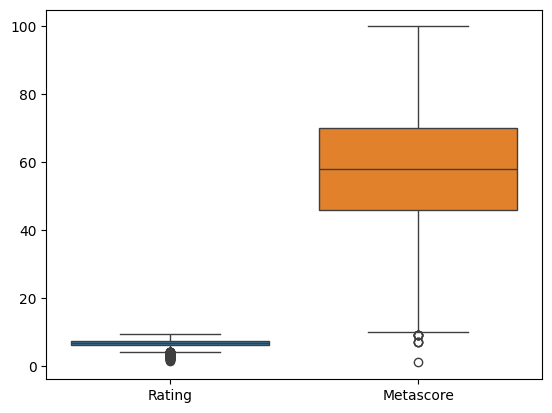

In [79]:
sns.boxplot(df)